In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data/online_retail_cleaned.csv")

df["TotalPrice"] = df["Quantity"] * df["Price"]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [3]:
rfm = df.groupby("Customer ID").agg({

    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "TotalPrice": "sum"

})

rfm.rename(columns={
    "InvoiceDate": "Recency",
    "Invoice": "Frequency",
    "TotalPrice": "Monetary"
}, inplace=True)

rfm.head()
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


In [4]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [5]:
rfm.shape

(5878, 3)

In [6]:
rfm.to_csv("results/customer_rfm.csv")

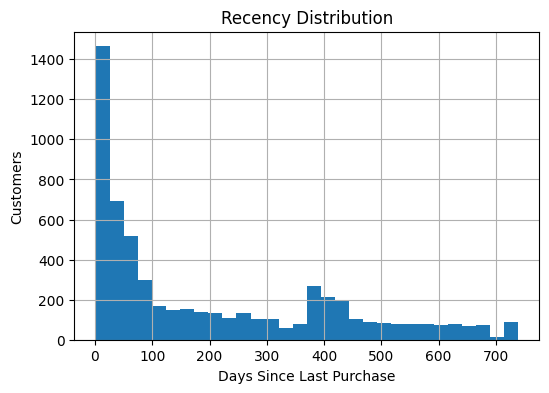

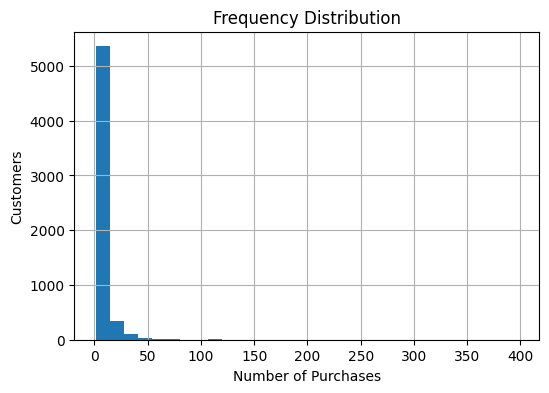

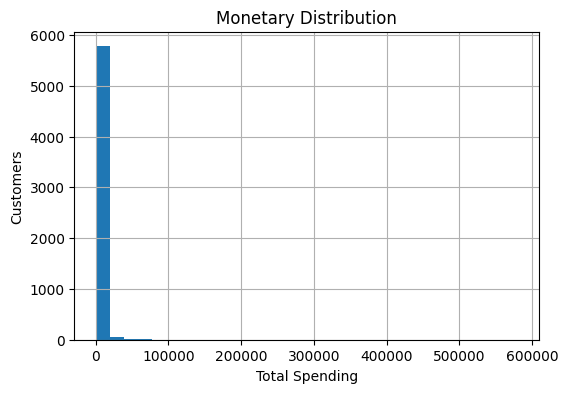

In [7]:
plt.figure(figsize=(6,4))
rfm["Recency"].hist(bins=30)
plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Customers")
plt.show()

plt.figure(figsize=(6,4))
rfm["Frequency"].hist(bins=30)
plt.title("Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Customers")
plt.show()

plt.figure(figsize=(6,4))
rfm["Monetary"].hist(bins=30)
plt.title("Monetary Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Customers")
plt.show()

In [8]:
rfm_log = rfm.copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

In [9]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency","Frequency","Monetary"],
    index=rfm_log.index
)

rfm_log.to_csv(
    "results/customer_rfm_log.csv"
)

In [10]:
print("Original RFM skew:")
print(rfm.skew())

print("\nLog RFM skew:")
print(rfm_log.skew())

Original RFM skew:
Recency       0.887198
Frequency    12.639951
Monetary     25.070190
dtype: float64

Log RFM skew:
Recency     -0.488631
Frequency    1.001471
Monetary     0.269125
dtype: float64


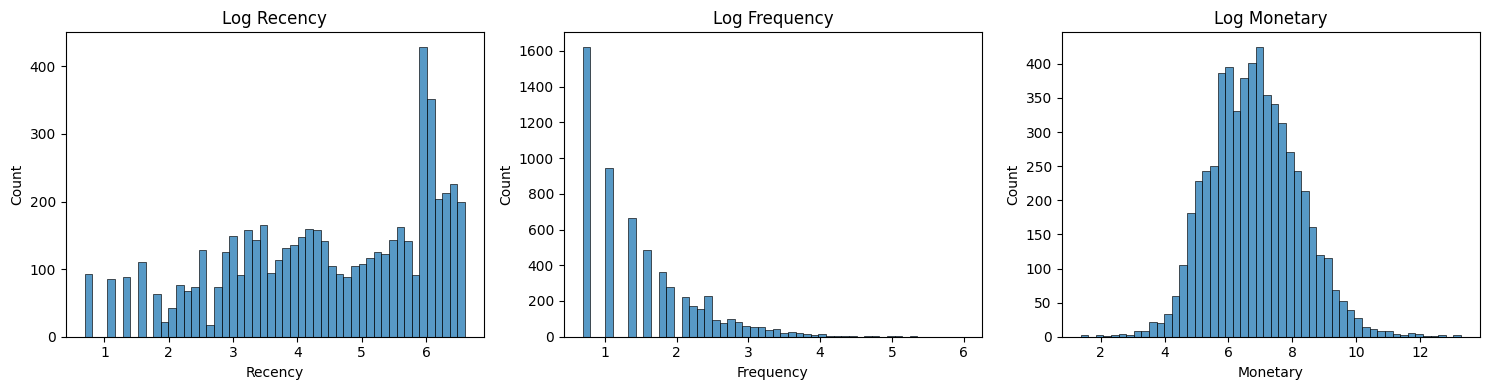

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(
    rfm_log["Recency"],
    bins=50,
    ax=axes[0]
)
axes[0].set_title("Log Recency")

sns.histplot(
    rfm_log["Frequency"],
    bins=50,
    ax=axes[1]
)
axes[1].set_title("Log Frequency")

sns.histplot(
    rfm_log["Monetary"],
    bins=50,
    ax=axes[2]
)
axes[2].set_title("Log Monetary")

plt.tight_layout()
plt.show()